In [ ]:
import random
from collections import defaultdict
from fastai.vision.all import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = Path('/content/drive/MyDrive/data/dataset_final')

all_files = get_image_files(path/'train') + get_image_files(path/'val')

random.seed(42)
files_by_class = defaultdict(list)
for f in all_files:
    files_by_class[parent_label(f)].append(f)

num_classes = len(files_by_class)
target_total = 30000
quota_per_class = target_total // num_classes

sampled_files = []
for font_class, files in files_by_class.items():
    k = min(quota_per_class, len(files))
    sampled_files.extend(random.sample(files, k=k))

print(f"Classes: {num_classes}, Quota/class: {quota_per_class}, Total: {len(sampled_files)}")

Classes: 150, Quota/class: 200, Total: 30000


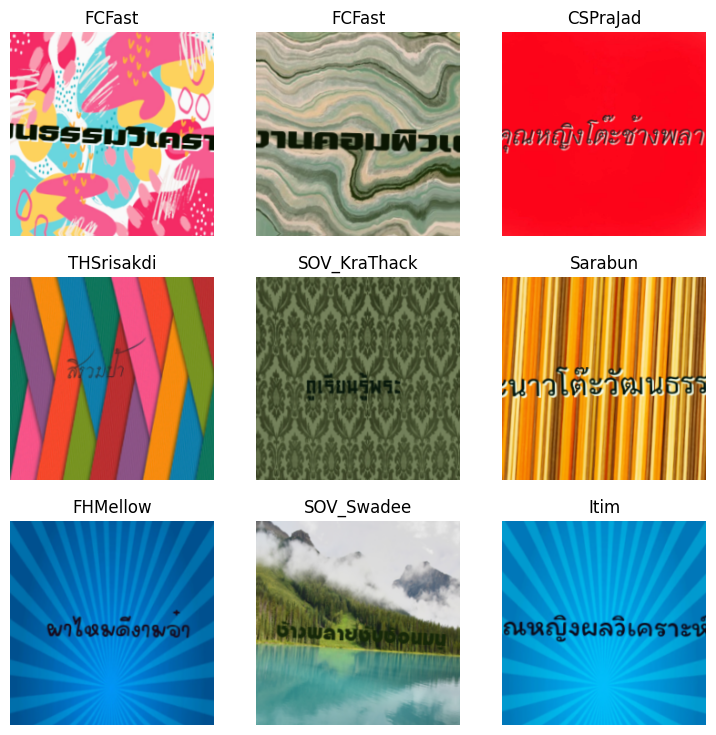

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda p: sampled_files,
    splitter=GrandparentSplitter(train_name='train', valid_name='val'),
    get_y=parent_label,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(
        mult=1.2,
        max_rotate=3.0,
        max_zoom=1.05,
        max_lighting=0.2,
        max_warp=0.0,
        do_flip=False,
    )
).dataloaders(path, bs=64, num_workers=4)

dls.show_batch(max_n=9)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 167MB/s] 


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,4.182232,2.857548,0.271816,0.243562,02:08
1,1.417770,0.977591,0.703937,0.691105,01:55
2,0.894506,0.551284,0.831762,0.827521,01:55
3,0.649194,0.436501,0.863344,0.861173,01:53
4,0.579684,0.395271,0.878910,0.877809,01:54


<div></div>

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,0.549759,0.388172,0.882353,0.881382,02:30
1,0.540555,0.372699,0.885945,0.884968,02:25
2,0.504896,0.373899,0.884598,0.883220,02:28
3,0.498909,0.342846,0.895674,0.895102,02:28
4,0.464305,0.327338,0.898668,0.897454,02:28
5,0.449977,0.316287,0.899865,0.899367,02:28
6,0.411364,0.285254,0.910043,0.909420,02:28
7,0.377135,0.265738,0.915582,0.914435,02:28
8,0.355817,0.245928,0.922616,0.921921,02:28
9,0.325261,0.227684,0.927406,0.927319,02:28


Better model found at epoch 0 with valid_loss value: 0.3881717026233673.
Better model found at epoch 1 with valid_loss value: 0.37269914150238037.
Better model found at epoch 3 with valid_loss value: 0.3428463637828827.
Better model found at epoch 4 with valid_loss value: 0.32733818888664246.
Better model found at epoch 5 with valid_loss value: 0.31628695130348206.
Better model found at epoch 6 with valid_loss value: 0.2852537930011749.
Better model found at epoch 7 with valid_loss value: 0.2657378017902374.
Better model found at epoch 8 with valid_loss value: 0.24592843651771545.
Better model found at epoch 9 with valid_loss value: 0.22768360376358032.
Better model found at epoch 10 with valid_loss value: 0.22429116070270538.
Better model found at epoch 11 with valid_loss value: 0.20532533526420593.
Better model found at epoch 12 with valid_loss value: 0.19891193509101868.
Better model found at epoch 13 with valid_loss value: 0.18597619235515594.
Better model found at epoch 14 with va

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


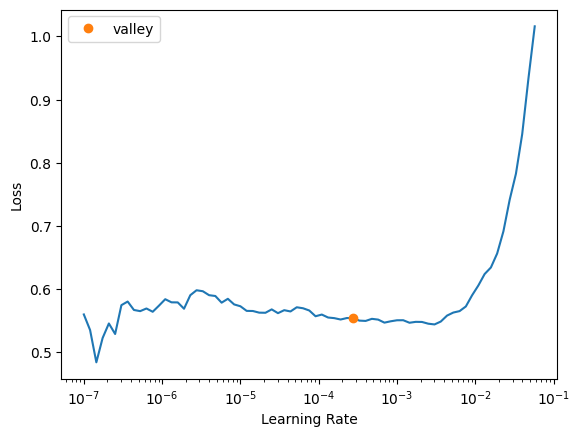

In [10]:
from torchvision.models import convnext_tiny

learn = vision_learner(
    dls, convnext_tiny,
    metrics=[accuracy, F1Score(average='weighted')],
    ps=0.3,
).to_fp16()

learn.freeze()
learn.fit_one_cycle(5, 1e-3, wd=0.01)

learn.lr_find()

learn.unfreeze()
learn.fit_one_cycle(
    30,
    lr_max=slice(1e-6, 3e-4),
    wd=0.01,
    cbs=[
        SaveModelCallback(monitor='valid_loss', fname='best_model_convnext'),
        EarlyStoppingCallback(monitor='valid_loss', patience=5),
    ]
)

learn.load('best_model_convnext')

In [11]:
test_files = get_image_files(path/'test')
test_dl = dls.test_dl(test_files, with_labels=True)
test_metrics = learn.validate(dl=test_dl)

preds_probs, targs = learn.get_preds(dl=test_dl)
preds_decoded = preds_probs.argmax(dim=1)

from sklearn.metrics import recall_score, precision_score, classification_report
print(f"Accuracy  : {test_metrics[1]:.4f}")
print(f"Recall    : {recall_score(targs, preds_decoded, average='weighted', zero_division=0):.4f}")
print(f"Precision : {precision_score(targs, preds_decoded, average='weighted', zero_division=0):.4f}")
print(classification_report(targs, preds_decoded, target_names=dls.vocab, zero_division=0))

import pandas as pd

report = classification_report(
    targs, preds_decoded,
    target_names=dls.vocab,
    zero_division=0,
    output_dict=True
)

df_report = pd.DataFrame(report).T.round(4)
df_report.to_csv("metrics_report.csv")
display(df_report)

Accuracy  : 0.9581
Recall    : 0.9581
Precision : 0.9595
                             precision    recall  f1-score   support

        304PANITangCampDemo       0.90      0.97      0.93        36
          305PANITheFoxDemo       1.00      1.00      1.00        36
          388PANIDekDeuDemo       0.97      0.89      0.93        36
         390PANIDoenPaaDemo       1.00      1.00      1.00        36
                    Arabica       1.00      0.94      0.97        36
                     Athiti       0.88      1.00      0.94        36
                BTN-Somboon       1.00      0.94      0.97        36
                BaiJamjuree       0.82      0.89      0.85        36
                       Boon       0.87      0.92      0.89        36
                 CSChatThai       0.90      0.78      0.84        36
                   CSPraJad       1.00      1.00      1.00        36
                   CSPraKas       0.92      0.94      0.93        36
                ChakraPetch       0.92      0

,precision,recall,f1-score,support
304PANITangCampDemo,0.8974,0.9722,0.9333,36.0000
305PANITheFoxDemo,1.0000,1.0000,1.0000,36.0000
388PANIDekDeuDemo,0.9697,0.8889,0.9275,36.0000
390PANIDoenPaaDemo,1.0000,1.0000,1.0000,36.0000
Arabica,1.0000,0.9444,0.9714,36.0000
...,...,...,...,...
rdkimchi,1.0000,1.0000,1.0000,36.0000
supermarket,0.9444,0.9444,0.9444,36.0000
accuracy,0.9581,0.9581,0.9581,0.9581
macro avg,0.9595,0.9581,0.9580,5400.0000


In [12]:
from google.colab import files
files.download("metrics_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[('FC Vision Wide', 'FCVision', np.int64(10)),
 ('SOV_KraThack', 'SOV_MumMong', np.int64(10)),
 ('Prompt', 'Kanit', np.int64(7)),
 ('FCVision', 'FC Vision Wide', np.int64(6)),
 ('NotoSansThai', 'Sukhumvit', np.int64(6)),
 ('Taviraj', 'Trirong', np.int64(5))]

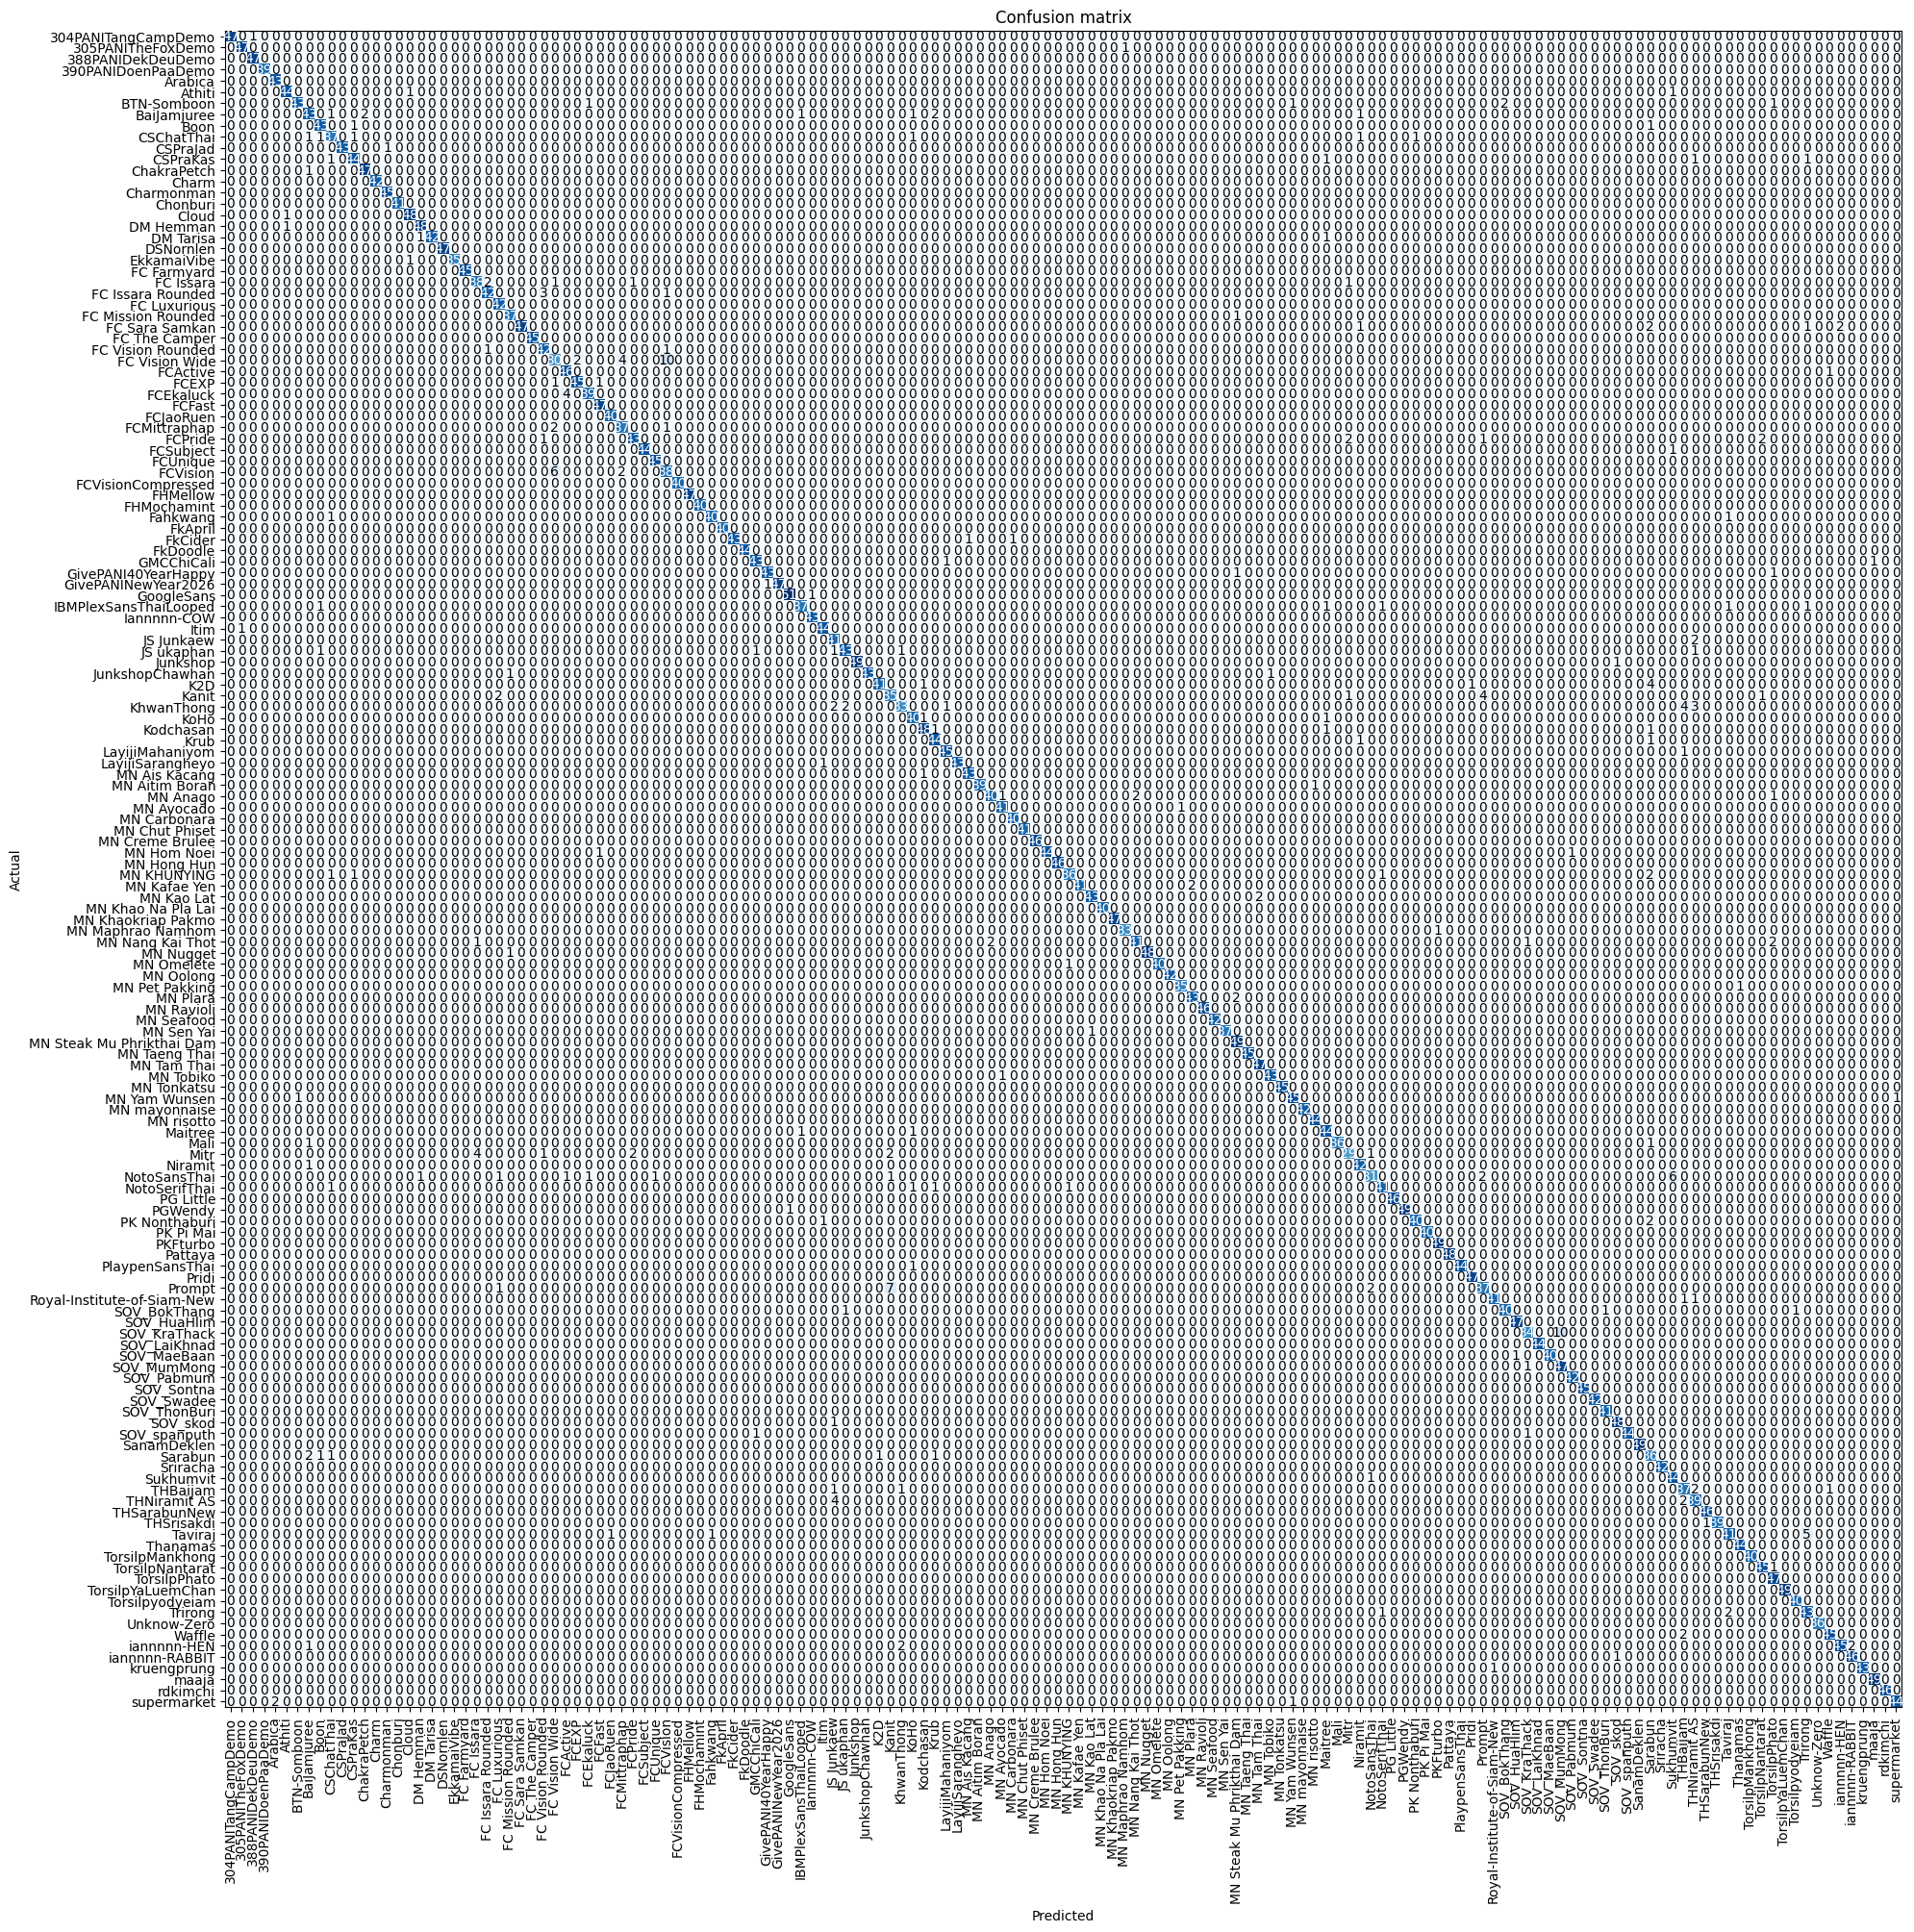

In [13]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(20, 20))
interp.most_confused(min_val=5)